<a href="https://www.kaggle.com/code/claudiotones/analisis-de-nicho-nu-metal-90?scriptVersionId=311674766" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Proyecto: Análsis de nicho - Nu Metal 90s
## Por: Claudiotones

✅ Análisis Técnico: Se detectaron 6 de 6 bandas.


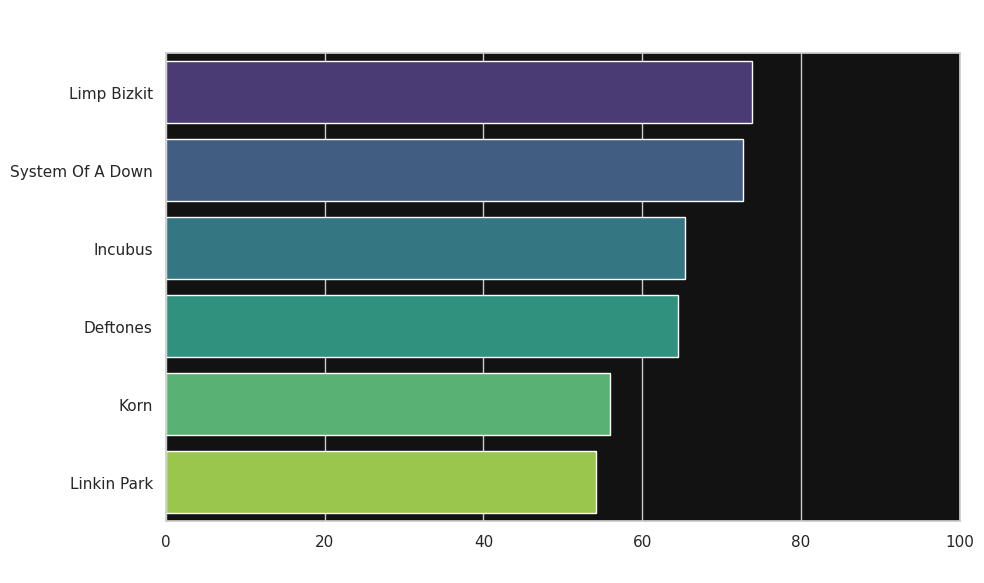

In [1]:
# ==========================================
# PROYECTO: ANÁLISIS DE NICHO - NU METAL 90s
# ==========================================

import kagglehub
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# 1. DESCARGA Y CARGA 
path = kagglehub.dataset_download("yashdev01/spotify-tracks-dataset")

# Buscador automático del CSV dentro de la descarga
csv_path = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_path = os.path.join(root, file)
            break

df_raw = pd.read_csv(csv_path)

# 2. UTILIDADES (Funciones de preprocesamiento)
def clean_column_names(df):
    """Limpia tildes, espacios y pasa a minúsculas las columnas."""
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(' ', '_', regex=False)
                  .str.replace('á', 'a').str.replace('é', 'e')
                  .str.replace('í', 'i').str.replace('ó', 'o').str.replace('ú', 'u'))
    return df

# 3. PROCESAMIENTO INICIAL
df = clean_column_names(df_raw)

# 4. ANÁLISIS DE NICHO NU METAL 90s
# Lista de bandas de interés
mis_bandas_objetivo = ['deftones', 'incubus', 'system of a down', 'linkin park', 'korn', 'limp bizkit']

# Filtro normalizando el texto para asegurar el match
df_lista = df[df['artists'].str.lower().str.strip().isin(mis_bandas_objetivo)].copy()

# Formateo de nombres para la visualización
df_lista['artists'] = df_lista['artists'].str.title()

# Eliminar duplicados priorizando la versión más popular
df_lista = df_lista.sort_values('popularity', ascending=False).drop_duplicates(subset=['track_name'])

# Verificación en consola
encontradas = df_lista['artists'].unique()
print(f"✅ Análisis Técnico: Se detectaron {len(encontradas)} de {len(mis_bandas_objetivo)} bandas.")

# 5. Visualización 
promedio_popularidad = df_lista.groupby('artists')['popularity'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
plt.style.use('dark_background')
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212"})

plot = sns.barplot(
    data=promedio_popularidad, 
    x='popularity', 
    y='artists', 
    hue='artists', 
    palette='viridis',
    legend=False
)

plt.title('Popularidad Promedio por Banda en Spotify', fontsize=15, pad=20, color='white')
plt.xlabel('Popularidad (Escala 0-100)', color='white')
plt.ylabel('', color='white')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

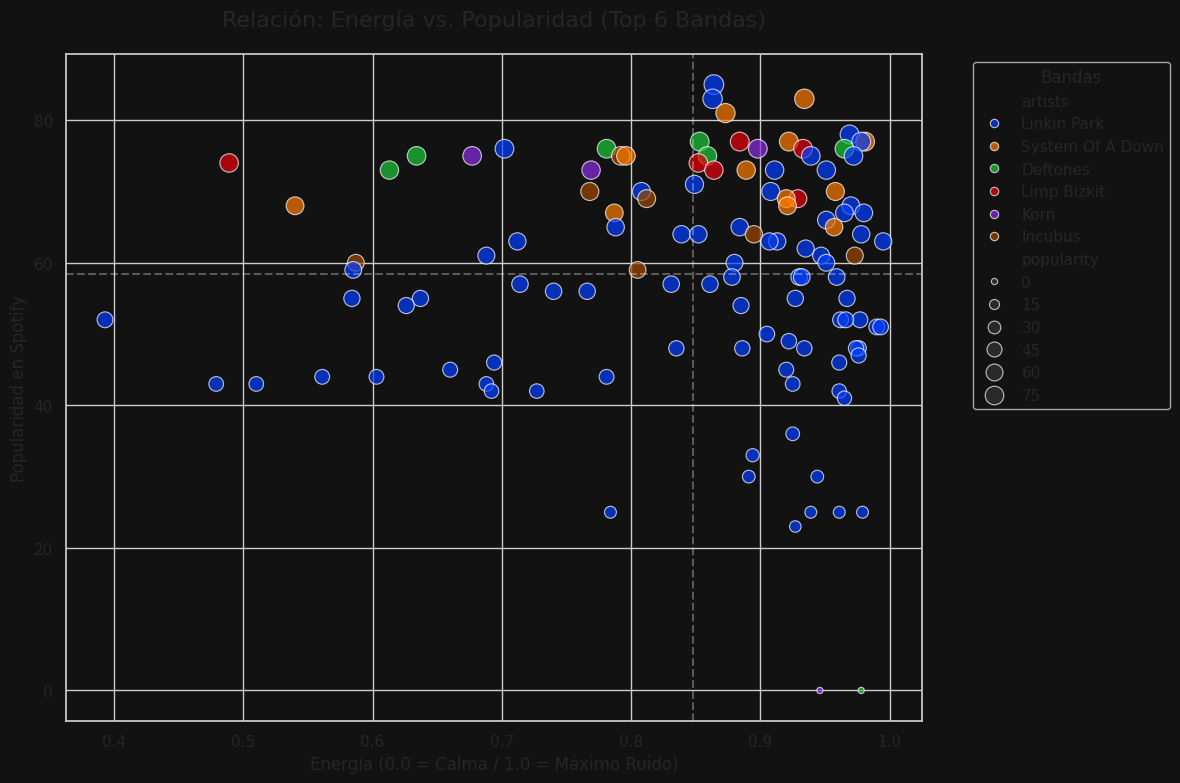

In [2]:
# 1. Configuración del gráfico
plt.figure(figsize=(12, 8))
plt.style.use('dark_background')
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212"})

# 2. Crear el Scatter Plot
# x = Energía, y = Popularidad, hue = Banda (para distinguir colores)
scatter = sns.scatterplot(
    data=df_lista, 
    x='energy', 
    y='popularity', 
    hue='artists', 
    size='popularity', # El tamaño del punto también indica popularidad
    palette='bright',
    alpha=0.7,         # Transparencia para ver puntos encimados
    sizes=(20, 200)    # Rango de tamaño de los puntos
)

# 3. Personalización técnica
plt.title('Relación: Energía vs. Popularidad (Top 6 Bandas)', fontsize=16, pad=20)
plt.xlabel('Energía (0.0 = Calma / 1.0 = Máximo Ruido)', fontsize=12)
plt.ylabel('Popularidad en Spotify', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Bandas') # Mueve la leyenda afuera

# 4. Líneas de referencia (Promedios)
plt.axhline(df_lista['popularity'].mean(), color='white', linestyle='--', alpha=0.3, label='Promedio Pop')
plt.axvline(df_lista['energy'].mean(), color='white', linestyle='--', alpha=0.3, label='Promedio Energy')

plt.tight_layout()
plt.show()

# Conclusiones del Análisis: Escena Nu-Metal y Alt-Rock

Tras procesar los datos de Spotify para las bandas seleccionadas (**Deftones, Incubus, System of a Down, Linkin Park, Korn y Limp Bizkit**), se identifican los siguientes puntos clave:

### 1. Popularidad vs. Energía
* **Consistencia en la Intensidad:** Bandas como *System of a Down* y *Limp Bizkit* muestran una concentración de canciones en niveles de energía superiores a 0.7, manteniendo una popularidad alta y estable. Son bandas que no "negocian" su potencia sonora.
  
* **Éxitos Atmosféricos:** Se observa que *Deftones* e *Incubus* logran posicionar canciones con menor energía (más atmosféricas o melódicas) en niveles de popularidad competitivos (70+). Esto sugiere una audiencia que valora tanto la agresividad como la textura musical.

### 2. Volumen de Hits
* **Linkin Park** destaca por tener la mayor cantidad de registros en el dataset, dominando el cuadrante de alta energía y alta popularidad. Esto refleja su impacto masivo y la vigencia de su catálogo en plataformas de streaming.

### 3. Notas Técnicas sobre los Datos
* Se aplicó una **normalización de texto** (`lower` y `strip`) para asegurar que el análisis incluyera todas las variantes de nombre de los artistas.
* Se eliminaron duplicados priorizando la versión de la canción con mayor puntaje de popularidad para no sesgar los promedios.